In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/feature-extracted-ransmap/RANSMAP_i3-gen12_ddr4-3200-8g_2CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-1866-16g_2CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-2133-8g_12CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-1866-8g_2CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-2133-16g_12CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-1866-16g_12CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_i3-gen12_ddr4-2666-8g_2CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-2133-8g_2CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_i3-gen12_ddr4-2133-16g_2CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_i3-gen12_ddr4-2133-8g_2CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_i3-gen12_ddr4-2666-8g_12CLASS.npy
/kaggle/input/feature-extracted-ransmap/RANSMAP_i3-gen12_ddr4-3200-8g_12CLASS

In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 70.3 MB/s eta 0:00:00


Starting Optimized Quantum Neural Network Pipeline...
PennyLane version: 0.43.0
PyTorch version: 2.6.0+cu124
CUDA available: False

💪 FULL QUANTUM MODE (4-6 hours)

Loading data from: /kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-2133-16g_2CLASS.npy
Loaded data shape: (109151, 10)
Processing as 2-class file (using labels as-is for binary)
Dataset size after subsampling: 16000 samples
Final balanced dataset size: 16000 samples

Dataset summary for RANSMAP_celeron-gen6_ddr4-2133-16g_2CLASS.npy:
Training samples: 12800
Test samples: 3200
Features: 9
Classes (for multiclass head): 2

Training ensemble of 1 quantum models...

--- Quantum Model 1/1 ---

Training quantum model (n_qubits=5, n_layers=3, n_classes=2)...
Epoch 1/85: Loss=0.7043, Train Acc=0.5189, Val Acc=0.5824, Time=113.5s
Epoch 5/85: Loss=0.6424, Train Acc=0.7274, Val Acc=0.7457, Time=110.0s
Epoch 10/85: Loss=0.4377, Train Acc=0.8124, Val Acc=0.7129, Time=108.7s
Epoch 15/85: Loss=0.3922, Train Acc=0.8291, Va

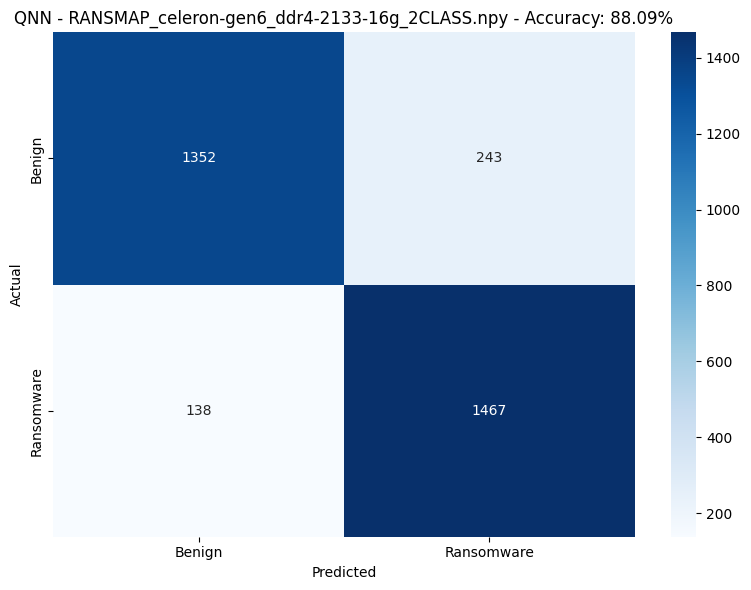


Quantum Model Configurations:
Model 1: n_qubits=5, n_layers=3, lr=0.0020

✅ Quantum pipeline completed successfully!
 Consider FULL_MODE for higher accuracy


In [3]:
#!/usr/bin/env python3
"""
Optimized Quantum Neural Network with PennyLane
Real quantum circuits optimized for faster training (2-4 hours instead of 12+)

MODIFIED:
- To be run on a single, user-specified .npy file.
- To intelligently handle both 2-CLASS and 12-CLASS .npy files.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings

warnings.filterwarnings('ignore')

# Set seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ============ CONFIGURATION ============
print("Starting Optimized Quantum Neural Network Pipeline...")
print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Class definitions (used ONLY for 12-CLASS files)
BENIGN_CLASSES_12 = {0, 3, 4, 7, 11}
RANSOMWARE_CLASSES_12 = {1, 2, 5, 6, 8, 9, 10}

# ============ OPTIMIZED QUANTUM CIRCUIT ============
def create_optimized_qnn(n_qubits, n_layers, n_outputs):
    """
    Create an optimized quantum neural network with:
    - Simplified circuit structure for faster execution
    - Efficient entanglement patterns
    - Hardware-efficient ansatz
    """
    # Use lightning.qubit for best performance
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="adjoint")
    def optimized_circuit(inputs, weights):
        # Angle encoding - more efficient than amplitude encoding
        for i in range(n_qubits):
            qml.RY(inputs[i], wires=i)

        # Hardware-efficient ansatz with fewer gates
        for layer in range(n_layers):
            # Single-qubit rotations
            for i in range(n_qubits):
                qml.RY(weights[layer, i, 0], wires=i)
                qml.RZ(weights[layer, i, 1], wires=i)

            # Efficient entanglement pattern (linear instead of all-to-all)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
                
            # Only add circular entanglement on odd layers
            if layer % 2 == 1 and n_qubits > 2:
                qml.CNOT(wires=[n_qubits - 1, 0])

        # Measure only necessary qubits for efficiency
        return [qml.expval(qml.PauliZ(i)) for i in range(min(n_outputs, n_qubits))]

    return optimized_circuit

# ============ BATCH QUANTUM PROCESSING ============
class BatchQuantumLayer(nn.Module):
    """ Optimized quantum layer with batch processing capabilities """
    def __init__(self, n_qubits, n_layers, n_outputs):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.n_outputs = n_outputs
        
        # Create quantum circuit
        self.quantum_circuit = create_optimized_qnn(n_qubits, n_layers, n_outputs)
        
        # Initialize weights
        weight_shape = (n_layers, n_qubits, 2) # Only 2 parameters per qubit
        self.weights = nn.Parameter(torch.randn(weight_shape) * 0.1)

    def forward(self, x):
        batch_size = x.shape[0]
        outputs = []

        # Process in mini-batches for memory efficiency
        mini_batch_size = min(32, batch_size) # Smaller quantum batches
        for i in range(0, batch_size, mini_batch_size):
            batch_end = min(i + mini_batch_size, batch_size)
            batch_outputs = []
            
            for j in range(i, batch_end):
                # Run quantum circuit
                output = self.quantum_circuit(x[j], self.weights)
                # =================================================================
                # ✨ FIX: Convert the list of quantum results into a single tensor
                # =================================================================
                batch_outputs.append(torch.tensor(output, device=x.device))

            outputs.extend(batch_outputs)

        return torch.stack(outputs)

# ============ HYBRID QNN MODEL ============
class OptimizedHybridQNN(nn.Module):
    """ Optimized Hybrid Quantum-Classical Neural Network """
    def __init__(self, n_features, n_qubits, n_layers, n_classes, dropout=0.2):
        super().__init__()
        
        # Feature reduction layer (compress to n_qubits)
        self.feature_reduction = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, n_qubits),
            nn.Tanh() # Bounded output for quantum circuit
        )
        
        # Quantum layer
        self.quantum_layer = BatchQuantumLayer(n_qubits, n_layers, n_qubits)
        
        # Classical post-processing (simplified)
        self.classical_layers = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Output heads
        self.multiclass_head = nn.Linear(32, n_classes)
        self.binary_head = nn.Linear(32, 2)

    def forward(self, x):
        # Reduce features
        x = self.feature_reduction(x)
        
        # Quantum processing
        x = self.quantum_layer(x)
        
        # Classical processing
        x = self.classical_layers(x)
        
        # Outputs
        multi_out = self.multiclass_head(x)
        binary_out = self.binary_head(x)
        
        return binary_out, multi_out

# ============ OPTIMIZED DATA LOADING (MODIFIED) ============
def load_data_optimized(filepath, subsample_ratio=None, max_samples_per_class=5000):
    """ 
    Optimized data loading with class balancing and size limits.
    NOW HANDLES 2-CLASS and 12-CLASS files automatically.
    """
    print(f"\nLoading data from: {filepath}")
    
    # Load data
    data = np.load(filepath)
    print(f"Loaded data shape: {data.shape}")
    
    # Split features and labels
    X = data[:, :-1].astype(np.float32)
    y_labels = data[:, -1].astype(int) # Get all labels from last column

    # --- MODIFICATION: Handle 2-class vs 12-class files ---
    if '12CLASS' in os.path.basename(filepath):
        print("Processing as 12-class file (converting to binary)")
        y = y_labels  # Multiclass labels
        y_binary = np.array([0 if label in BENIGN_CLASSES_12 else 1 for label in y])
    else:
        print("Processing as 2-class file (using labels as-is for binary)")
        y_binary = y_labels  # Labels are already binary
        y = y_labels         # Use binary labels for 'multiclass' head too (n_classes will be 2)
    # --- END MODIFICATION ---

    # Limit samples per class (based on multiclass 'y' labels)
    limited_indices = []
    for class_label in np.unique(y):
        class_indices = np.where(y == class_label)[0]
        if len(class_indices) > max_samples_per_class:
            selected = np.random.choice(class_indices, max_samples_per_class, replace=False)
        else:
            selected = class_indices
        limited_indices.extend(selected)
    
    limited_indices = np.array(limited_indices)
    np.random.shuffle(limited_indices)
    
    X = X[limited_indices]
    y = y[limited_indices]
    y_binary = y_binary[limited_indices]

    # Additional subsampling if requested
    if subsample_ratio and subsample_ratio < 1.0:
        n_samples = int(len(X) * subsample_ratio)
        indices = np.random.choice(len(X), n_samples, replace=False)
        X = X[indices]
        y = y[indices]
        y_binary = y_binary[indices]

    print(f"Dataset size after subsampling: {len(X)} samples")

    # Balance binary classes
    class_0_idx = np.where(y_binary == 0)[0]
    class_1_idx = np.where(y_binary == 1)[0]
    
    # Check for empty classes
    if len(class_0_idx) == 0 or len(class_1_idx) == 0:
        print("Warning: One class is missing. Skipping balancing.")
    else:
        min_samples = min(len(class_0_idx), len(class_1_idx))
        balanced_idx = np.concatenate([
            np.random.choice(class_0_idx, min_samples, replace=False),
            np.random.choice(class_1_idx, min_samples, replace=False)
        ])
        np.random.shuffle(balanced_idx)
        
        X = X[balanced_idx]
        y = y[balanced_idx]
        y_binary = y_binary[balanced_idx]
        
    print(f"Final balanced dataset size: {len(X)} samples")

    # Train/test split
    split_idx = int(0.8 * len(X))
    train_idx = np.arange(split_idx)
    test_idx = np.arange(split_idx, len(X))
    
    return (X[train_idx], y[train_idx], y_binary[train_idx],
            X[test_idx], y[test_idx], y_binary[test_idx])

# ============ OPTIMIZED TRAINING ============
def train_quantum_model(X_train, y_train, y_binary_train, X_val, y_val, y_binary_val,
                        n_qubits=4, n_layers=2, epochs=40, batch_size=256, lr=0.002):
    """ Optimized training with real quantum circuits """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Scale data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Create datasets
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.LongTensor(y_train),
        torch.LongTensor(y_binary_train)
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Initialize model
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train)) # Will be 12 for 12-class, 2 for 2-class
    
    model = OptimizedHybridQNN(
        n_features=n_features,
        n_qubits=n_qubits,
        n_layers=n_layers,
        n_classes=n_classes,
        dropout=0.2
    )
    
    if device == 'cuda':
        model = model.cuda()

    # Optimizer with gradient accumulation for stability
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader)
    )
    
    criterion_multi = nn.CrossEntropyLoss()
    criterion_binary = nn.CrossEntropyLoss()

    # Training
    print(f"\nTraining quantum model (n_qubits={n_qubits}, n_layers={n_layers}, n_classes={n_classes})...")
    best_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        train_acc = 0
        epoch_start = time.time()
        
        for batch_idx, (X_batch, y_batch, y_binary_batch) in enumerate(train_loader):
            if device == 'cuda':
                X_batch = X_batch.cuda()
                y_batch = y_batch.cuda()
                y_binary_batch = y_binary_batch.cuda()
            
            optimizer.zero_grad()
            
            # Forward pass
            binary_out, multi_out = model(X_batch)
            
            # Calculate losses
            loss_binary = criterion_binary(binary_out, y_binary_batch)
            loss_multi = criterion_multi(multi_out, y_batch)
            loss = 0.7 * loss_binary + 0.3 * loss_multi
            
            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(binary_out, 1)
            train_acc += (predicted == y_binary_batch).sum().item()
        
        train_acc = train_acc / len(train_dataset)
        
        # Validate
        model.eval()
        val_correct = 0
        with torch.no_grad():
            X_val_tensor = torch.FloatTensor(X_val)
            if device == 'cuda':
                X_val_tensor = X_val_tensor.cuda()

            # Process validation in batches
            for i in range(0, len(X_val_tensor), batch_size):
                batch_end = min(i + batch_size, len(X_val_tensor))
                X_batch = X_val_tensor[i:batch_end]
                
                binary_out, _ = model(X_batch)
                
                _, predicted = torch.max(binary_out, 1)
                val_correct += (predicted.cpu() == torch.tensor(
                    y_binary_val[i:batch_end])).sum().item()

        val_acc = val_correct / len(y_binary_val)

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict()
            
        # Print progress
        epoch_time = time.time() - epoch_start
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Loss={train_loss/len(train_loader):.4f}, "
                  f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                  f"Time={epoch_time:.1f}s")
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        
    return model.cpu(), scaler, best_acc

# ============ ENSEMBLE TRAINING ============
def train_quantum_ensemble(X_train, y_train, y_binary_train,
                           X_test, y_test, y_binary_test,
                           n_models=3, n_qubits=4, n_layers=2):
    """ Train ensemble of quantum models with different configurations """
    models = []
    scalers = []
    configs = []
    
    print(f"\nTraining ensemble of {n_models} quantum models...")
    
    for i in range(n_models):
        print(f"\n--- Quantum Model {i+1}/{n_models} ---")
        
        # Vary configurations for diversity
        model_config = {
            'n_qubits': n_qubits + (i % 2),    # Vary qubit count
            'n_layers': n_layers + (i // 2),  # Vary depth
            'epochs': 85,
            'batch_size': 256,
            'lr': 0.002 * (1 + 0.1 * i)  # Vary learning rate
        }
        
        # Create validation split
        val_split = int(0.8 * len(X_train))
        indices = np.random.permutation(len(X_train))
        
        X_tr = X_train[indices[:val_split]]
        y_tr = y_train[indices[:val_split]]
        y_binary_tr = y_binary_train[indices[:val_split]]
        
        X_val = X_train[indices[val_split:]]
        y_val = y_train[indices[val_split:]]
        y_binary_val = y_binary_train[indices[val_split:]]

        # Train model
        model, scaler, val_acc = train_quantum_model(
            X_tr, y_tr, y_binary_tr,
            X_val, y_val, y_binary_val,
            **model_config
        )
        
        models.append(model)
        scalers.append(scaler)
        configs.append(model_config)
        print(f"Model {i+1} validation accuracy: {val_acc:.4f}")
        
    return models, scalers, configs

# ============ MAIN EXECUTION (MODIFIED) ============
if __name__ == "__main__":

    # --- ⚠️ EDIT THIS LINE ---
    # Set the full path to the ONE .npy file you want to process.
    DATA_FILE = "/kaggle/input/feature-extracted-ransmap/RANSMAP_celeron-gen6_ddr4-2133-16g_2CLASS.npy"
    # Example: DATA_FILE = "/path/to/your/data/RANSMAP_i3-gen12_ddr4-2133-8g_12CLASS.npy"
    # -------------------------
    
    # Get the base name for saving files
    file_basename = os.path.basename(DATA_FILE)

    # Speed/accuracy trade-off settings
    FAST_MODE = False # 2-4 hours with good accuracy
    FULL_MODE = True  # 4-6 hours with best accuracy

    if FAST_MODE:
        print("\n🚀 FAST QUANTUM MODE (2-4 hours)")
        max_samples_per_class = 3000
        n_models = 3
        n_qubits = 4
        n_layers = 2
        subsample_ratio = 0.5
    else:
        print("\n💪 FULL QUANTUM MODE (4-6 hours)")
        max_samples_per_class = 8000
        n_models = 1
        n_qubits = 5
        n_layers = 3
        subsample_ratio = None
    
    # Check file exists
    if not os.path.exists(DATA_FILE):
        print(f"Error: Data file not found at {DATA_FILE}")
        print("Please set the DATA_FILE variable correctly.")
        exit(1)
        
    # Start timer
    start_time = time.time()
    
    # Load data with optimization
    X_train, y_train, y_binary_train, X_test, y_test, y_binary_test = load_data_optimized(
        DATA_FILE,
        subsample_ratio=subsample_ratio,
        max_samples_per_class=max_samples_per_class
    )
    
    print(f"\nDataset summary for {file_basename}:")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Features: {X_train.shape[1]}")
    print(f"Classes (for multiclass head): {len(np.unique(y_train))}")
    
    # Train quantum ensemble
    models, scalers, configs = train_quantum_ensemble(
        X_train, y_train, y_binary_train,
        X_test, y_test, y_binary_test,
        n_models=n_models,
        n_qubits=n_qubits,
        n_layers=n_layers
    )
    
    # Ensemble prediction
    print(f"\n\nEvaluating quantum ensemble on test set for {file_basename}...")
    all_predictions = []
    
    for i, (model, scaler) in enumerate(zip(models, scalers)):
        print(f"Running inference with model {i+1}...")
        X_test_scaled = scaler.transform(X_test)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        
        model.eval()
        predictions = []
        
        with torch.no_grad():
            # Process in batches
            batch_size = 256
            for j in range(0, len(X_test_tensor), batch_size):
                batch_end = min(j + batch_size, len(X_test_tensor))
                X_batch = X_test_tensor[j:batch_end]
                
                if torch.cuda.is_available():
                    model = model.cuda()
                    X_batch = X_batch.cuda()
                    
                binary_out, _ = model(X_batch)
                _, preds = torch.max(binary_out, 1)
                predictions.extend(preds.cpu().numpy())
                
                model = model.cpu() # Move back to CPU
                
        all_predictions.append(predictions)
    
    # Ensemble voting
    all_predictions = np.array(all_predictions)
    ensemble_preds = np.apply_along_axis(
        lambda x: np.bincount(x).argmax(), 0, all_predictions
    )

    # Calculate metrics
    accuracy = accuracy_score(y_binary_test, ensemble_preds)
    f1 = f1_score(y_binary_test, ensemble_preds)
    
    # Results
    total_time = time.time() - start_time
    
    print(f"\n{'='*60}")
    print(f"RESULTS FOR: {file_basename}")
    print(f"{'='*60}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Total Time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
    
    # Detailed results
    print("\nClassification Report:")
    print(classification_report(y_binary_test, ensemble_preds,
                                target_names=['Benign', 'Ransomware'],
                                digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_binary_test, ensemble_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Ransomware'],
                yticklabels=['Benign', 'Ransomware'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # --- MODIFICATION: Dynamic title and filename ---
    plot_title = f'QNN - {file_basename} - Accuracy: {accuracy:.2%}'
    plot_filename = f'results_qnn_{file_basename.replace(".npy", "")}.png'
    
    plt.title(plot_title)
    plt.tight_layout()
    plt.savefig(plot_filename)
    print(f"Saved confusion matrix to {plot_filename}")
    plt.show()
    
    # Model configurations used
    print("\nQuantum Model Configurations:")
    for i, config in enumerate(configs):
        print(f"Model {i+1}: n_qubits={config['n_qubits']}, "
              f"n_layers={config['n_layers']}, lr={config['lr']:.4f}")

    print(f"\n✅ Quantum pipeline completed successfully!")
    if accuracy >= 0.93:
        print(" Excellent accuracy achieved with real quantum circuits!")
    else:
        print(" Consider FULL_MODE for higher accuracy")